<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/oversampling_class-exxample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/010Ankushsharma/datasets/refs/heads/main/oversampling_dataset.csv')

In [3]:
print("\nOriginal Class Distribution:")
print(df['target'].value_counts())


Original Class Distribution:
target
0    87
1    13
Name: count, dtype: int64


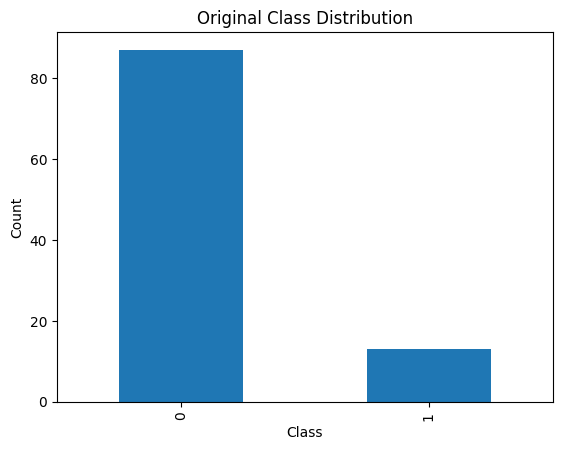

In [4]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [5]:
X = df.drop('target', axis=1)
y = df['target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
def evaluate_model(X_tr, y_tr, X_te, y_te, title):
    model = RandomForestClassifier(random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    print(f"\n===== {title} =====")
    print("Class Distribution:", Counter(y_tr))
    print("\nConfusion Matrix:\n", confusion_matrix(y_te, y_pred))
    print("\nClassification Report:\n", classification_report(y_te, y_pred))


In [8]:
evaluate_model(X_train, y_train, X_test, y_test, "Original Data")


===== Original Data =====
Class Distribution: Counter({0: 70, 1: 10})

Confusion Matrix:
 [[17  0]
 [ 3  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       0.00      0.00      0.00         3

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


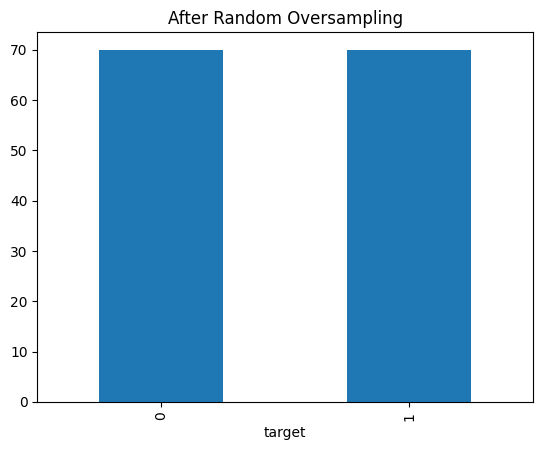


===== Random Oversampling =====
Class Distribution: Counter({0: 70, 1: 70})

Confusion Matrix:
 [[17  0]
 [ 1  2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       1.00      0.67      0.80         3

    accuracy                           0.95        20
   macro avg       0.97      0.83      0.89        20
weighted avg       0.95      0.95      0.95        20



In [9]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

plt.figure()
pd.Series(y_ros).value_counts().plot(kind='bar')
plt.title("After Random Oversampling")
plt.show()

evaluate_model(X_ros, y_ros, X_test, y_test, "Random Oversampling")

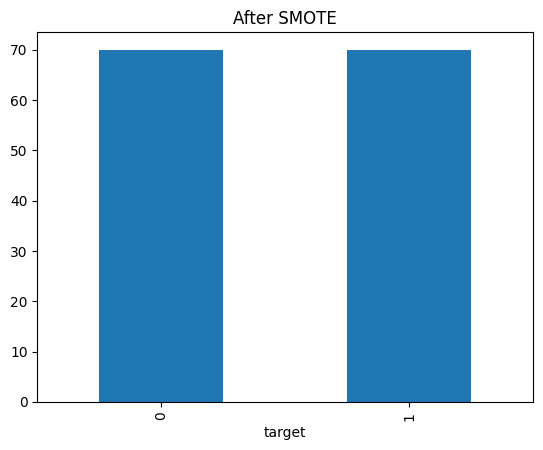


===== SMOTE =====
Class Distribution: Counter({0: 70, 1: 70})

Confusion Matrix:
 [[14  3]
 [ 1  2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.40      0.67      0.50         3

    accuracy                           0.80        20
   macro avg       0.67      0.75      0.69        20
weighted avg       0.85      0.80      0.82        20



In [10]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

plt.figure()
pd.Series(y_smote).value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.show()

evaluate_model(X_smote, y_smote, X_test, y_test, "SMOTE")


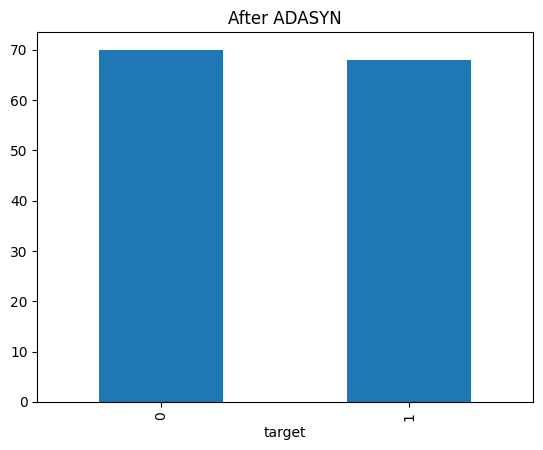


===== ADASYN =====
Class Distribution: Counter({0: 70, 1: 68})

Confusion Matrix:
 [[14  3]
 [ 2  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85        17
           1       0.25      0.33      0.29         3

    accuracy                           0.75        20
   macro avg       0.56      0.58      0.57        20
weighted avg       0.78      0.75      0.76        20



In [11]:
adasyn = ADASYN(random_state=42)
X_ada, y_ada = adasyn.fit_resample(X_train, y_train)

plt.figure()
pd.Series(y_ada).value_counts().plot(kind='bar')
plt.title("After ADASYN")
plt.show()

evaluate_model(X_ada, y_ada, X_test, y_test, "ADASYN")